Accuracy: 0.73
Precision: 0.76
Recall: 0.73
F1-Score: 0.68
Matthews Correlation Coefficient: 0.6538
Cohen's Kappa: 0.6296
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.23      0.37       100
meningioma_tumor       0.74      0.96      0.84       115
        no_tumor       0.72      1.00      0.84       105
 pituitary_tumor       0.63      0.65      0.64        74

        accuracy                           0.73       394
       macro avg       0.75      0.71      0.67       394
    weighted avg       0.76      0.73      0.68       394



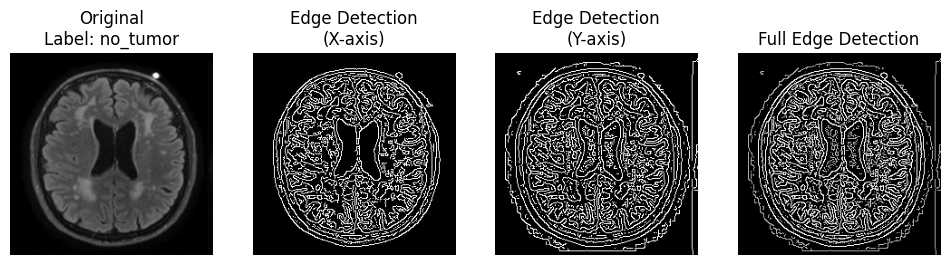

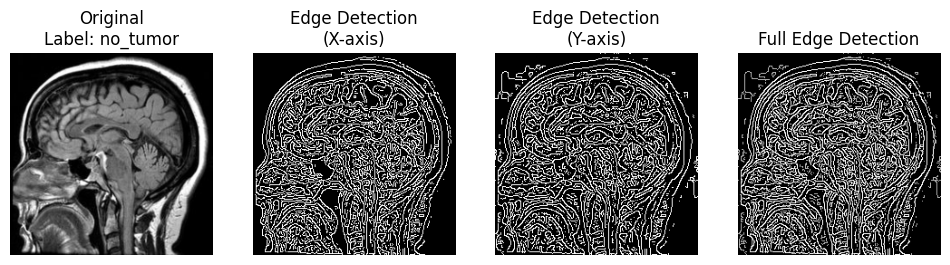

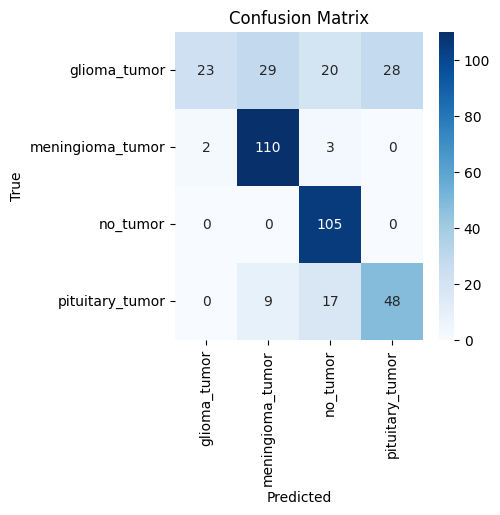

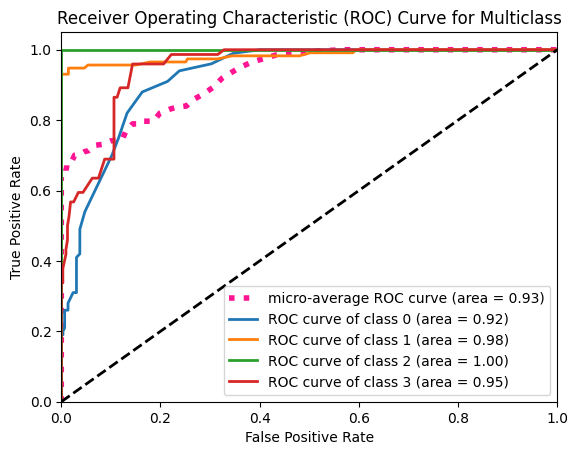

In [ ]:
import os
import zipfile
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, matthews_corrcoef, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Use the original file paths to the .zip files
train_zip_path = '/content/Training.zip.zip' # This was originally assigned to train_dir
test_zip_path = '/content/Testing.zip.zip'  # This was originally assigned to test_dir

# Load and preprocess images
def load_images_from_folder(folder):
    images = []
    labels = []
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue
        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (224, 224))
                images.append(img)
                labels.append(label)
    return images, labels

# Apply the Canny operator
def apply_canny_operator(image):
    cannyx = cv2.Canny(image, cv2.CV_64F, 50, 100, apertureSize=3)
    cannyy = cv2.Canny(image, cv2.CV_64F,100, 300, apertureSize=5)
    gradient_magnitude = np.sqrt(cannyx**2 + cannyy**2)
    return cannyx, cannyy, gradient_magnitude

# Display images
def display_images(images, labels):
    for idx, image in enumerate(images):
        cannyx, cannyy, gradient_magnitude = apply_canny_operator(image)

        plt.figure(figsize=(12, 6))

        # Original Image
        plt.subplot(1, 4, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'Original\nLabel: {labels[idx]}')
        plt.axis('off')

        # Edge Detection (X-axis)
        plt.subplot(1, 4, 2)
        plt.imshow(cannyx, cmap='gray')
        plt.title('Edge Detection\n(X-axis)')
        plt.axis('off')

        # Edge Detection (Y-axis)
        plt.subplot(1, 4, 3)
        plt.imshow(cannyy, cmap='gray')
        plt.title('Edge Detection\n(Y-axis)')
        plt.axis('off')

        # Full Edge Detection
        plt.subplot(1, 4, 4)
        plt.imshow(gradient_magnitude, cmap='gray')
        plt.title('Full Edge Detection')
        plt.axis('off')


# Load training and testing data
train_dir = '/content/Training.zip.zip'
test_dir = '/content/Testing.zip.zip'

# Extract the zip files
# Assuming the extracted folders will be named 'Training' and 'Testing'
# Change these names if necessary
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')
with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Load training and testing data using the extracted folder paths
train_dir = '/content/Training' # Path to the extracted training folder
test_dir = '/content/Testing'  # Path to the extracted testing folder

X_train, y_train = load_images_from_folder(train_dir)
X_test, y_test = load_images_from_folder(test_dir)

# Display images with edge detection
display_images(X_train[:2], y_train[:2])  # Display first 2 images and their edges

# Apply canny operator to the training and testing sets
X_train_canny = np.array([apply_canny_operator(img) for img in X_train])
X_test_canny = np.array([apply_canny_operator(img) for img in X_test])

# Flatten the features
X_train_canny_flat = X_train_canny.reshape(len(X_train_canny), -1)
X_test_canny_flat = X_test_canny.reshape(len(X_test_canny), -1)

# Convert labels to numeric format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Function to train with epochs
def train_with_epochs(clf, X_train, y_train, X_test, y_test, epochs=30):
    for epoch in range(epochs):
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f'Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.2f}')
        return clf

# Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_canny_flat, y_train)

# Make predictions
y_pred = clf.predict(X_test_canny_flat)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f'Matthews Correlation Coefficient: {mcc:.4f}')

# Cohen's Kappa
cohen_kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {cohen_kappa:.4f}")

# Classification report
report = classification_report(y_test, y_pred, target_names=list(le.classes_))
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(le.classes_), yticklabels=list(le.classes_))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC curve and AUC for multiclass
# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], clf.predict_proba(X_test_canny_flat)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), clf.predict_proba(X_test_canny_flat).ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multiclass')
plt.legend(loc="lower right")
plt.show()
